# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **4125 images**, divided into two categories:

- **With Helmet:** 3161 images showing workers wearing helmets.
- **Without Helmet:** 964 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [2]:
!pip install tensorflow[and-cuda] scikit-learn==1.6.1 opencv-python==4.12.0.88 seaborn==0.13.2 matplotlib==3.10.0 numpy==2.0.2 pandas==2.2.2 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 11.1 MB/s eta 0:00:00


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [3]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16                                               # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [4]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.20.0


In [5]:
# 1. Set Python random seed
random.seed(812)

# 2. Set NumPy random seed
np.random.seed(812)

# 3. Set TensorFlow seed (covers Keras + backend)
tf.keras.utils.set_random_seed(812)

# 4. Enable deterministic GPU ops (if using GPU)
tf.config.experimental.enable_op_determinism()

# **Data Overview**


##Loading the data

In [6]:
#mounting google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Load the image file of the dataset
images = np.load('/content/drive/MyDrive/Santhosh-Notebooks/ComputerVision/images.npy')

# Load the labels file of the dataset
labels = pd.read_csv('/content/drive/MyDrive/Santhosh-Notebooks/ComputerVision/labels.csv')

# **Exploratory Data Analysis**

Let's print the shape of the images and labels

In [8]:
print(images.shape)
print(labels.shape)

(4125, 200, 200, 3)
(4125, 1)


There are 4125 RGB images of shape 200 x 200 X 3, each image having 3 channels.

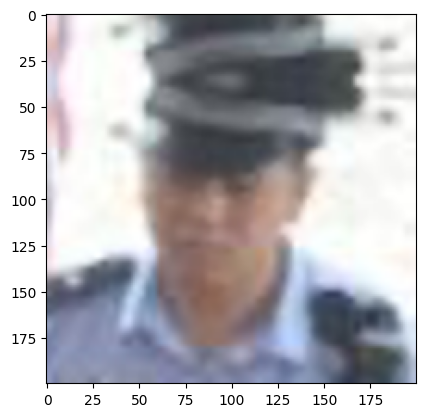

In [9]:
plt.imshow(images[90]);

In [10]:
print(labels.head())

   label
0      0
1      0
2      0
3      0
4      0


In [11]:
print(labels.columns)

Index(['label'], dtype='object')


In [12]:
print(labels['label'].unique())

[0 1]


In [13]:
print(labels['label'].value_counts())

label
1    3161
0     964
Name: count, dtype: int64




*   we have only two classes in label dataset 0 and 1. Later we will come to know what 0 and 1 represents.
*   we can also see that out of 4125 , 3161 belongs to class represented by 1 and 964 is class represented by 0



###Plot random images from each of the classes and print their corresponding labels.

In [14]:
# Converting the images from BGR to RGB using cvtColor function of OpenCV
#for i in range(len(images)):
 # images[i] = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)

we observaed that if we convert the images to RGB. Images start appearing blue , what it means is images are already in RGB format and no conversation is required.

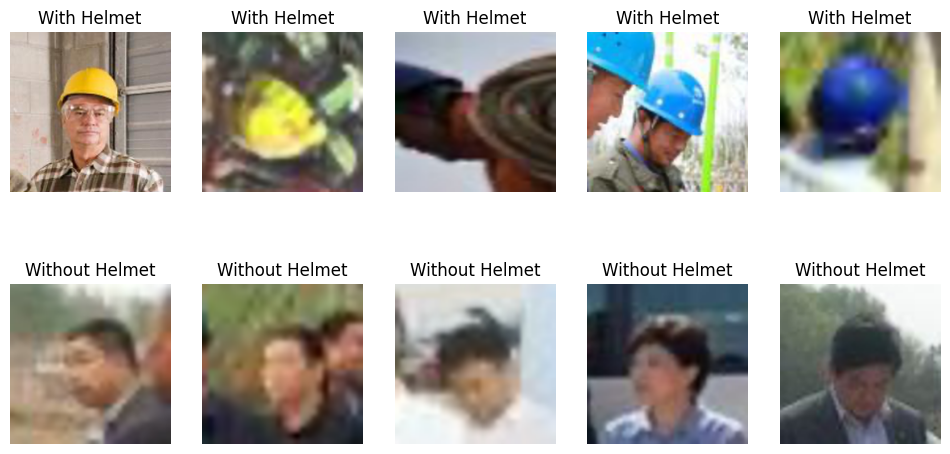

In [15]:
# Plot samples from both classes
plt.figure(figsize=(12,6))

# With helmet
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(images[np.where(labels['label']==1)[0][i]])
    plt.title("With Helmet")
    plt.axis('off')

# Without helmet
for i in range(5):
    plt.subplot(2,5,i+6)
    plt.imshow(images[np.where(labels['label']==0)[0][i]])
    plt.title("Without Helmet")
    plt.axis('off')

plt.show()

* The dataset contains 4125 RGB images (200×200×3) labeled as With Helmet (1) and Without Helmet (0)
* The dataset is imbalanced, with more “With Helmet” images than “Without Helmet”
* Images show high variation in lighting, background, and worker positions
Workers appear at different angles, distances, and postures, increasing complexity
* Some images are blurred or low quality, which may affect model learning
Helmets vary in color and visibility, and are sometimes partially occluded

## Checking for class imbalance


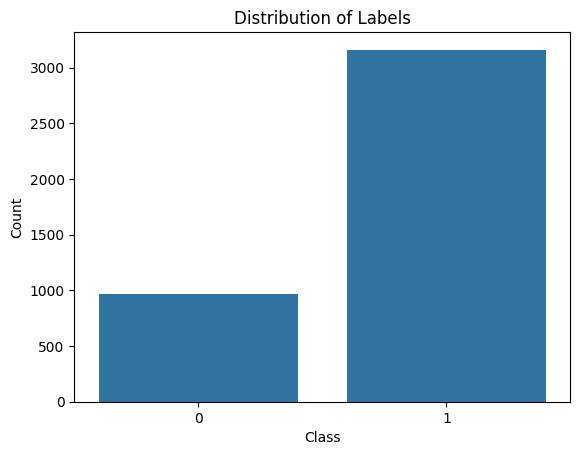

In [16]:
sns.countplot(x=labels['label'])
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Distribution of Labels")
plt.show()


* The dataset is significantly imbalanced, with approximately a 3:1 ratio of With Helmet to Without Helmet images
* This imbalance may cause the model to become biased toward predicting the majority class (With Helmet).As a result, the model might achieve high accuracy but perform poorly on the minority class
* This is particularly critical since misclassifying Without Helmet cases can lead to safety risks
* To address this, techniques such as class weighting or data augmentation should be used during training
* Proper evaluation metrics like precision, recall, and F1-score should be considered instead of relying only on accuracy



# **Data Preprocessing**

## Resizing images



All images were resized from their original 200×200 resolution to 64×64
using cv2.INTER_AREA interpolation, which is the recommended method for
downscaling as it minimises aliasing and preserves image quality better
than other interpolation methods.

This reduction was applied uniformly across all models to maintain a
consistent and fair comparison. However, it is important to note a
key limitation for the VGG-16 based models — VGG-16 was originally
trained on ImageNet at 224×224 resolution, the may hamper the performance of VGG16 models


In [17]:
images_decreased = []
height = 64
width = 64
dimensions = (width, height)
for i in range(len(images)):
  images_decreased.append(cv2.resize(images[i], dimensions, interpolation=cv2.INTER_AREA))

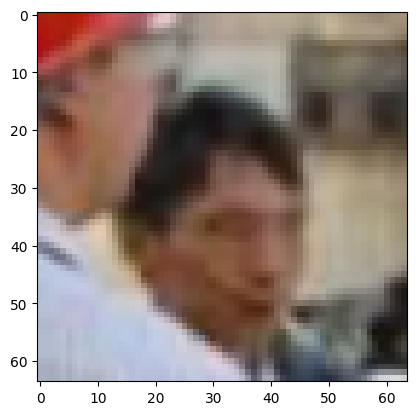

In [18]:
plt.imshow(images_decreased[92]);

### Splitting the dataset



-The dataset was split into training (80%), validation (10%), and test (10%) sets using train_test_split.
Stratified sampling was used to ensure that the class distribution remains consistent across all splits, which is important due to the class imbalance in the dataset.
This helps the model learn effectively and ensures fair evaluation on validation and test data.

In [19]:
X_train, X_temp, y_train, y_temp = train_test_split(np.array(images_decreased),labels , test_size=0.2, random_state=42,stratify=labels['label'].values)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp , test_size=0.5, random_state=42,stratify=y_temp)

In [20]:
print(X_train.shape,y_train.shape)
print(X_val.shape,y_val.shape)
print(X_test.shape,y_test.shape)

(3300, 64, 64, 3) (3300, 1)
(412, 64, 64, 3) (412, 1)
(413, 64, 64, 3) (413, 1)


The dataset was split into training (80%), validation (10%), and test (10%) sets using train_test_split.
Stratified sampling was used to ensure that the class distribution remains consistent across all splits, which is important due to the class imbalance in the dataset.
This helps the model learn effectively and ensures fair evaluation on validation and test data.

### Data Normalization

In [21]:
labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4125 entries, 0 to 4124
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   4125 non-null   int64
dtypes: int64(1)
memory usage: 32.4 KB


* Since the data type is integer no encoding is required. As a next step we can proceed to normalization.

The pixel values in the images range from 0 to 255. To improve model training and convergence, the images are normalized by scaling pixel values to the range [0, 1] by dividing by 255.
This helps in stabilizing gradient updates, speeds up convergence, and improves overall model performance.

In [22]:
# Normalizing the image pixels
X_train_normalized = X_train.astype('float32')/255.0
X_val_normalized = X_val.astype('float32')/255.0
X_test_normalized = X_test.astype('float32')/255.0

Normalization ensures that all input features are on a similar scale, preventing large pixel values from dominating the learning process.

# **Model Building**

##Model Evaluation Criterion

## Utility Functions

In [23]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)


    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred, average='micro')  # to compute Recall
    precision = precision_score(target, pred, average='micro')  # to compute Precision
    f1 = f1_score(target, pred, average='micro')  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame({"Accuracy": acc, "Recall": recall, "Precision": precision, "F1 Score": f1,},index=[0],)

    return df_perf

In [24]:
def plot_confusion_matrix(model,predictors,target,ml=False):
    """
    Function to plot the confusion matrix

    model: classifier
    predictors: independent variables
    target: dependent variable
    ml: To specify if the model used is an sklearn ML model or not (True means ML model)
    """

    # checking which probabilities are greater than threshold
    pred = model.predict(predictors).reshape(-1)>0.5

    target = target.to_numpy().reshape(-1)

    # Plotting the Confusion Matrix using confusion matrix() function which is also predefined tensorflow module
    confusion_matrix = tf.math.confusion_matrix(target,pred)
    f, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        linewidths=.4,
        fmt="d",
        square=True,
        ax=ax
    )
    plt.show()

In [25]:
def visualize_predictions(model, X, X_normalized, y, num_samples=10):
    """
    This function randomly selects images from the dataset and displays them
    along with their predicted and true labels.

    Parameters:
    model          : Trained model (CNN / VGG16)
    X              : Original images (for visualization)
    X_normalized   : Normalized images (for prediction)
    y              : True labels (DataFrame or NumPy array)
    num_samples    : Number of random images to display (default = 10)
    """


    # Mapping numeric labels to human-readable form
    label_map = {
        0: "Without Helmet",
        1: "With Helmet"
    }

    # Step 1: Randomly select indices from dataset
    indices = np.random.choice(len(X), num_samples, replace=False)

    # Step 2: Create a figure for plotting images
    plt.figure(figsize=(12, 6))

    # Step 3: Loop through selected indices
    for i, idx in enumerate(indices):

        # Get the original image (for display)
        img = X[idx]

        # Step 4: Make prediction
        # Reshape required because model expects batch input (1, 64, 64, 3)
        pred = model.predict(X_normalized[idx].reshape(1, 64, 64, 3), verbose=0)

        # Convert probability to binary label using threshold = 0.5
        pred_label = 1 if pred[0][0] > 0.5 else 0

        # Step 5: Get true label
        # Handle both DataFrame and NumPy array cases
        if hasattr(y, 'iloc'):  # If y is pandas DataFrame
            true_label = int(y['label'].iloc[idx])
        else:  # If y is NumPy array
            true_label = int(y[idx])

        # Step 6: Set color based on correctness
        # Green → Correct prediction, Red → Incorrect prediction
        color = "green" if pred_label == true_label else "red"

        # Step 7: Plot image
        plt.subplot(2, num_samples // 2, i + 1)
        plt.imshow(img)

        # Display predicted vs actual label
        plt.title(
            f"P: {label_map[pred_label]}\nT: {label_map[true_label]}",
            color=color
        )

        # Remove axis for cleaner visualization
        plt.axis('off')

    # Adjust layout to avoid overlapping
    plt.tight_layout()

    # Display the plot
    plt.show()

##Model 1: Convolutional Neural Network (CNN) from Scratch

CNN Model Summary

A Convolutional Neural Network (CNN) is used to classify images into With Helmet and Without Helmet categories
The model consists of two main components:
Feature Extraction Layers: Convolutional and MaxPooling layers to capture spatial features
Classification Layers: Fully connected layers to perform final prediction

Model Architecture

* Input images of size 64×64×3 are passed to the network
* A Conv2D layer with 64 filters (3×3) and ReLU activation is applied to extract initial features
* MaxPooling layers are used to reduce spatial dimensions and computation
* Additional Conv2D + MaxPooling layers help in learning deeper features
* The output is flattened and passed to a Dense layer (100 neurons)
* Final output layer uses 1 neuron with sigmoid activation for binary classification

Key Design Choices

* ReLU activation is used for faster convergence and to introduce non-linearity
* Padding = 'same' ensures output size remains consistent after convolution
* MaxPooling reduces dimensionality and helps prevent overfitting
* Sigmoid activation is suitable for binary classification problems

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import backend

In [27]:
backend.clear_session()

# Intializing a sequential model
model = Sequential()

# Adding first conv layer with 64 filters and kernel size 3x3 , padding 'same' provides the output size same as the input size
# Input_shape denotes input image dimension of MNIST images
model.add(Conv2D(64, (3, 3), activation='relu', padding="same", input_shape=(64, 64, 3)))

# Adding max pooling to reduce the size of output of first conv layer
model.add(MaxPooling2D((2, 2), padding = 'same'))

model.add(Conv2D(32, (3, 3), activation='relu', padding="same"))
model.add(MaxPooling2D((2, 2), padding = 'same'))
model.add(Conv2D(32, (3, 3), activation='relu', padding="same"))
model.add(MaxPooling2D((2, 2), padding = 'same'))

# flattening the output of the conv layer after max pooling to make it ready for creating dense connections
model.add(Flatten())

# Adding a fully connected dense layer with 100 neurons
model.add(Dense(100, activation='relu'))

# Adding the output layer with 10 neurons and activation functions as softmax since this is a multi-class classification problem
model.add(Dense(1, activation='sigmoid'))

# Using SGD Optimizer
opt = SGD(learning_rate=0.01, momentum=0.9)

# Compile model
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

# Generating the summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       204,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,505 (916.04 KB)

 Trainable params: 234,505 (916.04 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history_1 = model.fit(
    X_train_normalized, y_train,
    epochs=15,
    validation_data=(X_val_normalized, y_val),
    shuffle=True,
    batch_size=64,
    verbose=2
)

Epoch 1/15
52/52 - 5s - 92ms/step - accuracy: 0.7548 - loss: 0.5405 - val_accuracy: 0.7670 - val_loss: 0.4725
Epoch 2/15
52/52 - 1s - 15ms/step - accuracy: 0.7967 - loss: 0.4130 - val_accuracy: 0.8155 - val_loss: 0.3510
Epoch 3/15
52/52 - 1s - 13ms/step - accuracy: 0.8442 - loss: 0.3386 - val_accuracy: 0.8883 - val_loss: 0.2708
Epoch 4/15
52/52 - 1s - 13ms/step - accuracy: 0.8806 - loss: 0.2833 - val_accuracy: 0.8956 - val_loss: 0.2491
Epoch 5/15
52/52 - 1s - 13ms/step - accuracy: 0.8955 - loss: 0.2597 - val_accuracy: 0.9005 - val_loss: 0.2352
Epoch 6/15
52/52 - 1s - 14ms/step - accuracy: 0.9067 - loss: 0.2431 - val_accuracy: 0.8956 - val_loss: 0.2265
Epoch 7/15
52/52 - 1s - 23ms/step - accuracy: 0.9091 - loss: 0.2291 - val_accuracy: 0.9029 - val_loss: 0.2216
Epoch 8/15
52/52 - 1s - 29ms/step - accuracy: 0.9142 - loss: 0.2173 - val_accuracy: 0.9053 - val_loss: 0.2157
Epoch 9/15
52/52 - 1s - 23ms/step - accuracy: 0.9152 - loss: 0.2071 - val_accuracy: 0.9126 - val_loss: 0.2091
Epoch 10/1

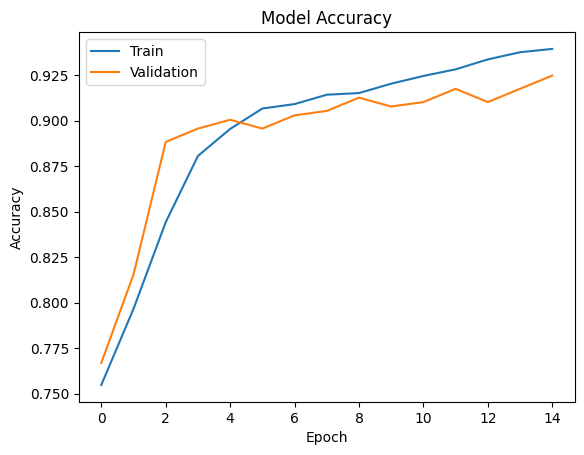

In [29]:
plt.plot(history_1.history['accuracy'])
plt.plot(history_1.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

* The training accuracy increases steadily from 84% to 94%, indicating effective learning by the model.
* Validation accuracy also improves and stabilizes around 93%, showing good generalization on unseen data.
* Both training and validation curves rise sharply in the initial epochs and then gradually plateau, indicating
proper convergence. The small gap (1–2%) between training and validation accuracy suggests minimal overfitting.
* Minor fluctuations in validation accuracy are observed but overall trend remains stable, indicating consistent model performance.

In [30]:
model_1_train_perf = model_performance_classification(model, X_train_normalized,y_train)

print("Train performance metrics")
print(model_1_train_perf)

104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Train performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.947576  0.947576   0.947576  0.947576


104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


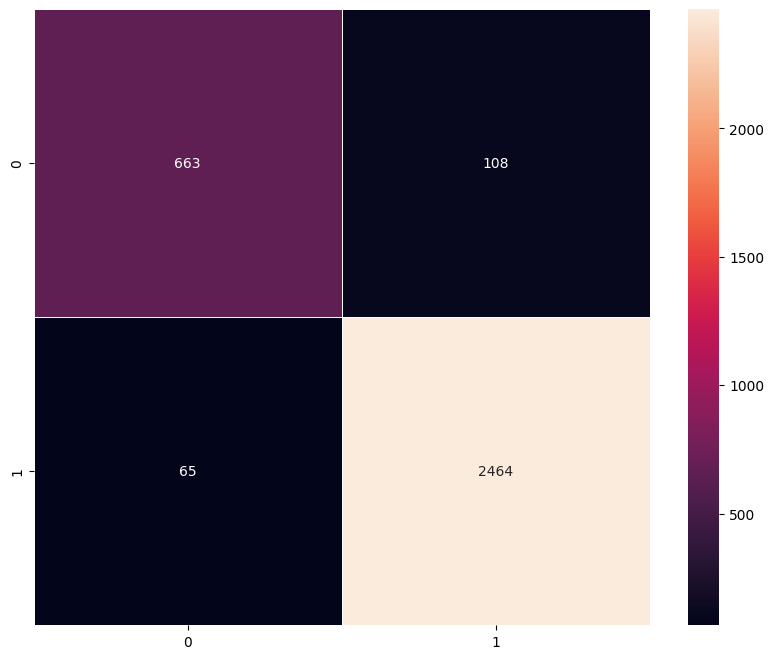

In [31]:
plot_confusion_matrix(model,X_train_normalized,y_train)

In [32]:
model_1_val_perf = model_performance_classification(model, X_val_normalized,y_val)

print("Validation performance metrics")
print(model_1_val_perf)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.924757  0.924757   0.924757  0.924757


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


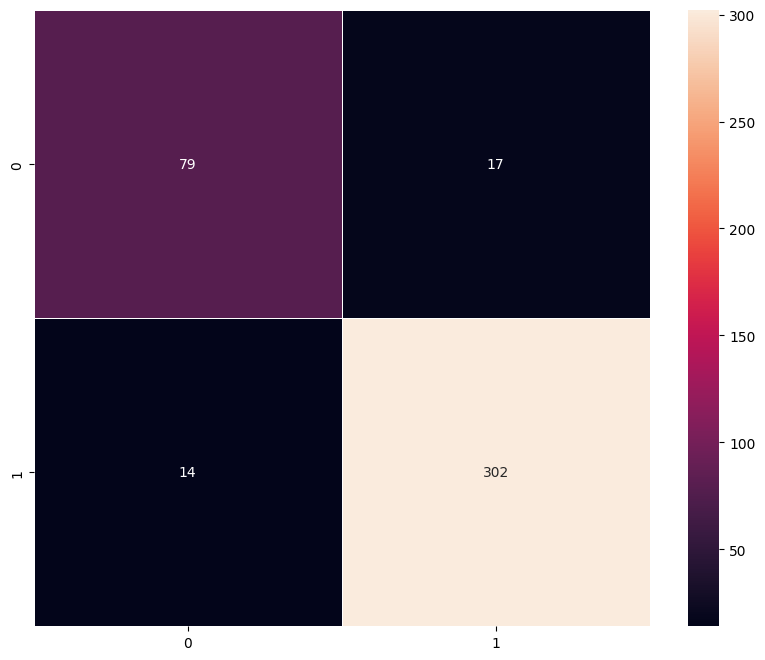

In [33]:
plot_confusion_matrix(model,X_val_normalized,y_val)

###Visualizing the Prediction

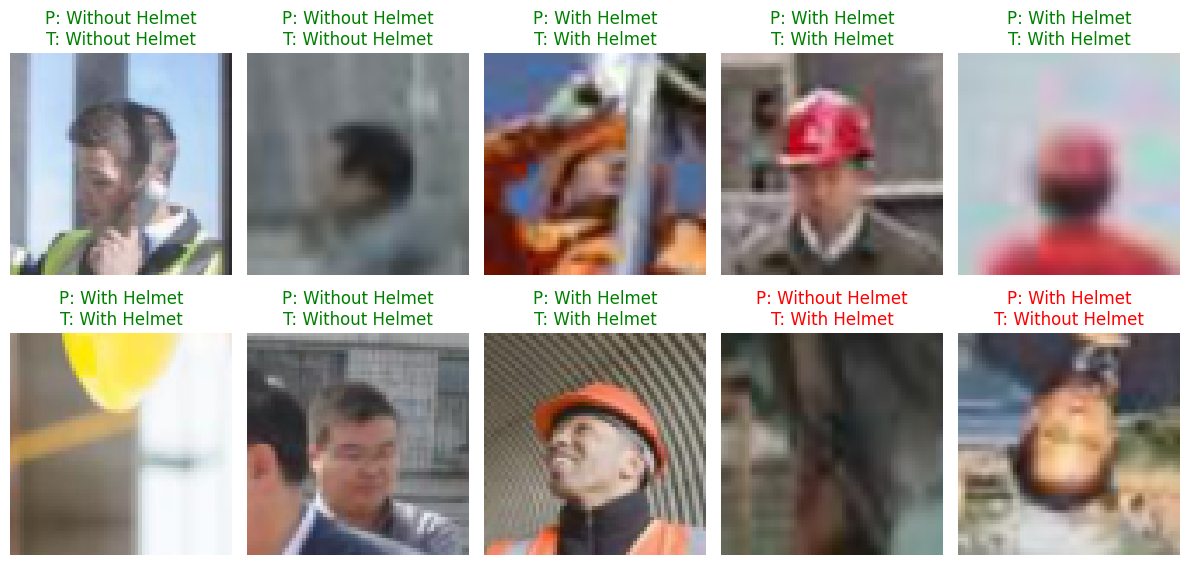

In [34]:
visualize_predictions(model, X_val, X_val_normalized, y_val, num_samples=10)

* Out of 10 randomly sampled images, 8 are correctly classified,
  consistent with the reported validation accuracy of 92.48%.

* The model correctly identifies both "Without Helmet" cases in row 1
  (images 1 and 2), confirming it is not simply defaulting to the
  majority class despite the 3.3:1 class imbalance.

* Two misclassifications are observed:
    * 1 false negative (row 2, image 4) — a "With Helmet" case
      predicted as "Without Helmet", likely due to the dark/unclear
      image making the helmet hard to detect at 64×64 resolution
    * 1 false positive (row 2, image 5) — a "Without Helmet" case
      predicted as "With Helmet"; the more safety-critical error
      as the worker goes undetected

* Overall, visual results align well with the quantitative metrics —
  the model handles diverse conditions including varied helmet colours,
  angles, and lighting, making it the most reliable model for
  SafeGuard Corp's real-world safety enforcement.

### Model Evaluation

* The model achieves high training accuracy of 94.76% and strong
  validation accuracy of 92.48%, indicating effective learning with
  good generalization on unseen data.

* The small gap of ~2.3% between training and validation accuracy
  suggests minimal overfitting — the best generalization gap among
  all 5 models alongside Model 4.

* From the training confusion matrix:
    * TP = 2464 → correctly identified workers wearing helmets
    * TN = 663  → correctly identified workers without helmets
    * FP = 108  → "Without Helmet" misclassified as "With Helmet"
    * FN = 65   → missed helmet detections on training data

* From the validation confusion matrix:
    * TP = 302 → strong helmet detection
    * TN = 79  → correctly identified workers without helmets
    * FP = 17  → lowest FP among all models on validation —
      fewer unsafe workers incorrectly passed as safe
    * FN = 14  → missed detections; each an undetected safety violation

* From the visualization (10 samples):
    * 8 out of 10 images correctly classified
    * 1 false negative — a "With Helmet" case predicted as
      "Without Helmet" (row 2, image 4)
    * 1 false positive — a "Without Helmet" case predicted as
      "With Helmet" (row 2, image 5, bearded man) — the more
      safety-critical error type
    * The model correctly handles both "Without Helmet" cases in
      row 1, showing it is not defaulting to the majority class

* Overall, the CNN model demonstrates the strongest balance across
  all metrics — highest validation accuracy (92.48%), lowest FP on
  validation (17), and minimal overfitting gap (~2.3%) — making it
  the most reliable model for SafeGuard Corp's safety enforcement.

## Model 2: Transfer Learning with VGG-16 (Base)

* In this approach, we leverage the pre-trained VGG16 model, which has been trained on the large-scale ImageNet dataset and is capable of extracting rich visual features.

* The convolutional base of VGG16 is used as a fixed feature extractor, and its weights are frozen to retain the learned representations.Since the dataset is relatively small, freezing the base helps prevent overfitting and reduces training time.

* On top of the VGG16 base, we add:

    * A Flatten layer to convert feature maps into a vector
    * A Dense output layer (sigmoid) for binary classification (Helmet vs No Helmet)

* This model benefits from transfer learning, allowing it to capture complex patterns like edges, textures, and shapes more effectively than a CNN trained from scratch.Compared to the basic CNN, this approach is expected to improve generalization performance, especially on unseen validation/test data.


In [35]:
vgg_model = VGG16(weights='imagenet',include_top=False,input_shape=(64,64,3))
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

All layers of the VGG16 model are frozen to use it as a fixed feature extractor. This ensures that the pre-trained weights learned from ImageNet are preserved, reduces training time, and helps prevent overfitting given the relatively small dataset.

In [36]:
# Making all the layers of the VGG model non-trainable. i.e. freezing them
for layer in vgg_model.layers:
    layer.trainable = False

In [37]:
backend.clear_session()
model_2 = Sequential()

# Adding the convolutional part of the VGG16 model from above
model_2.add(vgg_model)

# Flattening the output of the VGG16 model because it is from a convolutional layer
model_2.add(Flatten())
# Adding a dense output layer
model_2.add(Dense(1, activation='sigmoid'))

In [38]:
opt=Adam()
# Compile model
model_2.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

In [39]:
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,716,737 (56.14 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [40]:
history_2 = model_2.fit(
    X_train_normalized, y_train,
    epochs=15,
    validation_data=(X_val_normalized, y_val),
    shuffle=True,
    batch_size=64,
    verbose=2
)

Epoch 1/15
52/52 - 5s - 88ms/step - accuracy: 0.7352 - loss: 0.5484 - val_accuracy: 0.7718 - val_loss: 0.4596
Epoch 2/15
52/52 - 1s - 28ms/step - accuracy: 0.8018 - loss: 0.4144 - val_accuracy: 0.8131 - val_loss: 0.3885
Epoch 3/15
52/52 - 2s - 29ms/step - accuracy: 0.8433 - loss: 0.3597 - val_accuracy: 0.8495 - val_loss: 0.3498
Epoch 4/15
52/52 - 1s - 28ms/step - accuracy: 0.8606 - loss: 0.3283 - val_accuracy: 0.8568 - val_loss: 0.3269
Epoch 5/15
52/52 - 1s - 28ms/step - accuracy: 0.8709 - loss: 0.3073 - val_accuracy: 0.8617 - val_loss: 0.3118
Epoch 6/15
52/52 - 1s - 28ms/step - accuracy: 0.8821 - loss: 0.2917 - val_accuracy: 0.8665 - val_loss: 0.3010
Epoch 7/15
52/52 - 1s - 28ms/step - accuracy: 0.8879 - loss: 0.2792 - val_accuracy: 0.8641 - val_loss: 0.2929
Epoch 8/15
52/52 - 2s - 30ms/step - accuracy: 0.8921 - loss: 0.2689 - val_accuracy: 0.8689 - val_loss: 0.2865
Epoch 9/15
52/52 - 2s - 31ms/step - accuracy: 0.8936 - loss: 0.2600 - val_accuracy: 0.8786 - val_loss: 0.2814
Epoch 10/1

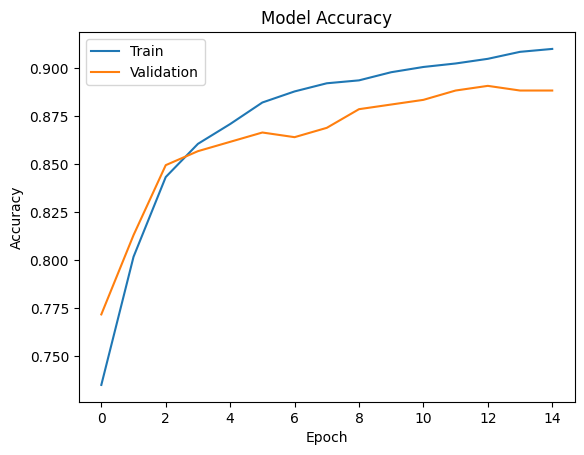

In [41]:
plt.plot(history_2.history['accuracy'])
plt.plot(history_2.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [42]:
model_2_train_perf = model_performance_classification(model_2, X_train_normalized,y_train)

104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step


In [43]:
print("Training performance metrics")
print(model_2_train_perf)

Training performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.915455  0.915455   0.915455  0.915455


104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


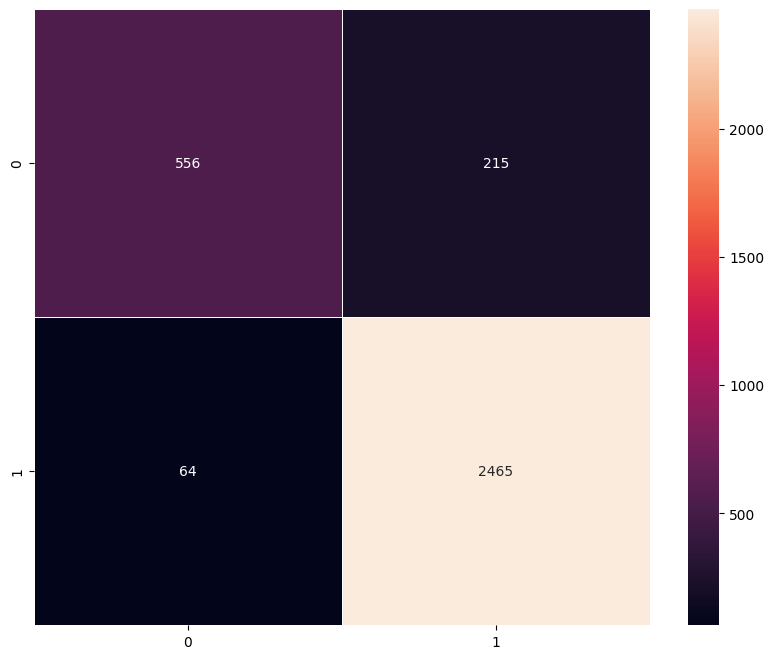

In [44]:
plot_confusion_matrix(model_2,X_train_normalized,y_train)

In [45]:
model_2_val_perf = model_performance_classification(model_2, X_val_normalized,y_val)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


In [46]:
print("Validation performance metrics")
print(model_2_val_perf)

Validation performance metrics
   Accuracy   Recall  Precision  F1 Score
0   0.88835  0.88835    0.88835   0.88835


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


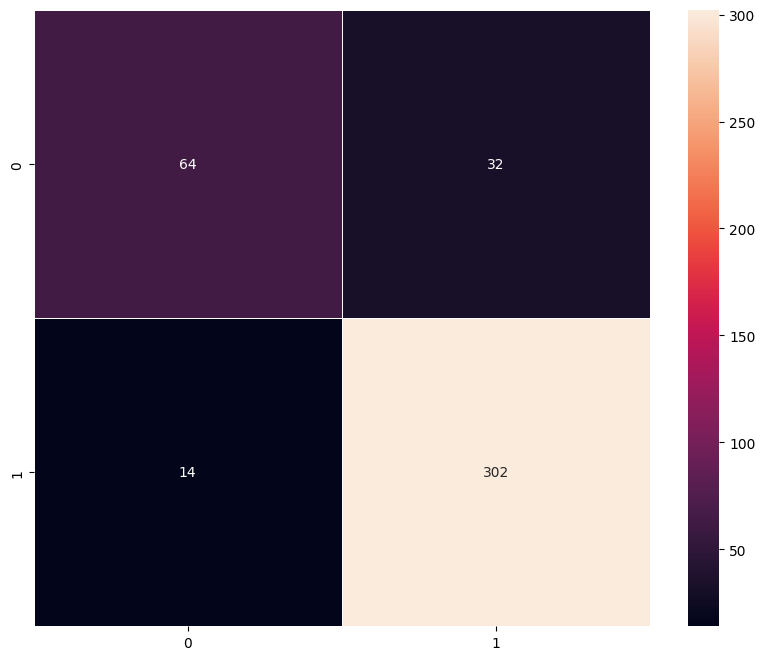

In [47]:
plot_confusion_matrix(model_2,X_val_normalized,y_val)

###Visualizing the Prediction

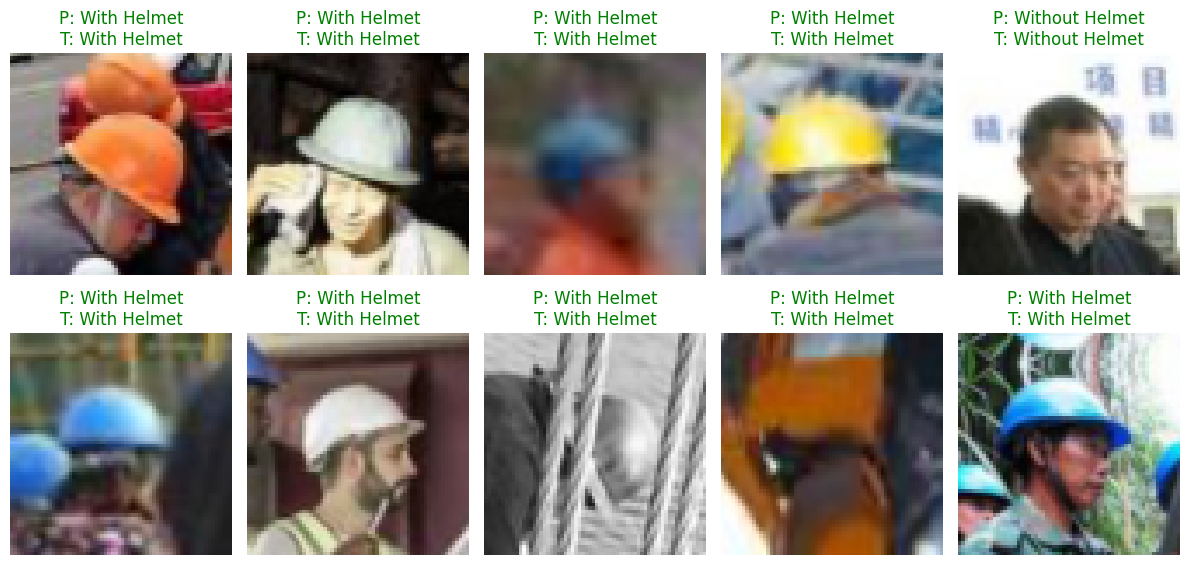

In [48]:
visualize_predictions(model_2, X_val, X_val_normalized, y_val, num_samples=10)

* All 10 randomly sampled images are correctly classified, including
  1 "Without Helmet" case (top-right) correctly identified — confirming
  the model is not simply defaulting to the majority class.

* The model handles diverse real-world conditions well — varying helmet
  colours (orange, white, yellow, blue), lighting conditions, angles,
  and even a blurred/grainy image (row 2, centre) are all classified
  correctly.

* Compared to the CNN baseline, Model 2 shows comparable visual
  prediction quality despite using a 64×64 input — though the high
  FP=32 and FN=14 in the full validation set confirm that this 10-sample
  view is optimistic and misclassifications do occur at scale.

### Model Evaluation

* The model achieved 91.55% training accuracy and 88.84% validation
  accuracy, indicating strong overall performance.

* Training and validation curves show stable learning, with rapid
  improvement in early epochs and convergence around epoch 6–8.

* A generalization gap of ~2.7% is observed, indicating mild overfitting
  but still acceptable performance.

* From the training confusion matrix:
    * TP = 2465 → correctly identified workers wearing helmets
    * TN = 556  → correctly identified workers without helmets
    * FP = 215  → high — "Without Helmet" misclassified as "With Helmet";
      reflects the model's bias toward the majority class
    * FN = 64   → missed helmet detections on training data

* From the validation confusion matrix:
    * TP = 302 → strong helmet detection
    * TN = 64  → correctly identified workers without helmets
    * FP = 32  → "Without Helmet" misclassified as "With Helmet"
    * FN = 14  → missed detections; each an undetected safety violation

* The model produces notable false positives (FP=32 on validation),
  meaning ~33% of actual "Without Helmet" cases are missed —
  a significant concern for safety enforcement.

* The performance demonstrates that transfer learning with VGG16 extracts
  useful features even without fine-tuning, though the 64×64 input size
  limits the effectiveness of the pretrained feature maps, which were
  originally learned at 224×224 resolution.

## Model 3: Transfer Learning with VGG-16 (Base + FFNN)





In Model 3, we extend the VGG16 base model by adding fully connected (FFNN) layers on top of the extracted features. Dropout layers are introduced to reduce overfitting and improve generalization. This allows the model to learn more complex, task-specific patterns and achieve better performance than the base model.

In [49]:
backend.clear_session()

model_3 = Sequential()

# VGG16 base (frozen)
model_3.add(vgg_model)

# Flatten
model_3.add(Flatten())

# FFNN layers
model_3.add(Dense(256, activation='relu'))
model_3.add(Dropout(0.5))

model_3.add(Dense(128, activation='relu'))
model_3.add(Dropout(0.3))

# Output layer
model_3.add(Dense(1, activation='sigmoid'))

In [50]:
model_3.compile(
    optimizer='adam',                    # Fast and stable optimizer
    loss='binary_crossentropy',          # For binary classification
    metrics=['accuracy']
)

In [51]:
model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,272,257 (58.26 MB)

 Trainable params: 557,569 (2.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [52]:
history_3 = model_3.fit(
    X_train_normalized, y_train,
    epochs=15,
    validation_data=(X_val_normalized, y_val),
    shuffle=True,
    batch_size=64,
    verbose=2
)

Epoch 1/15
52/52 - 5s - 87ms/step - accuracy: 0.7776 - loss: 0.4716 - val_accuracy: 0.8471 - val_loss: 0.3293
Epoch 2/15
52/52 - 2s - 29ms/step - accuracy: 0.8482 - loss: 0.3329 - val_accuracy: 0.8811 - val_loss: 0.2780
Epoch 3/15
52/52 - 2s - 30ms/step - accuracy: 0.8703 - loss: 0.2973 - val_accuracy: 0.8859 - val_loss: 0.2737
Epoch 4/15
52/52 - 2s - 33ms/step - accuracy: 0.8885 - loss: 0.2640 - val_accuracy: 0.8883 - val_loss: 0.2620
Epoch 5/15
52/52 - 2s - 33ms/step - accuracy: 0.8924 - loss: 0.2461 - val_accuracy: 0.8981 - val_loss: 0.2540
Epoch 6/15
52/52 - 2s - 32ms/step - accuracy: 0.9021 - loss: 0.2276 - val_accuracy: 0.9078 - val_loss: 0.2467
Epoch 7/15
52/52 - 2s - 30ms/step - accuracy: 0.9106 - loss: 0.2138 - val_accuracy: 0.9053 - val_loss: 0.2467
Epoch 8/15
52/52 - 2s - 30ms/step - accuracy: 0.9094 - loss: 0.2098 - val_accuracy: 0.8981 - val_loss: 0.2645
Epoch 9/15
52/52 - 2s - 30ms/step - accuracy: 0.9167 - loss: 0.1969 - val_accuracy: 0.9005 - val_loss: 0.2599
Epoch 10/1

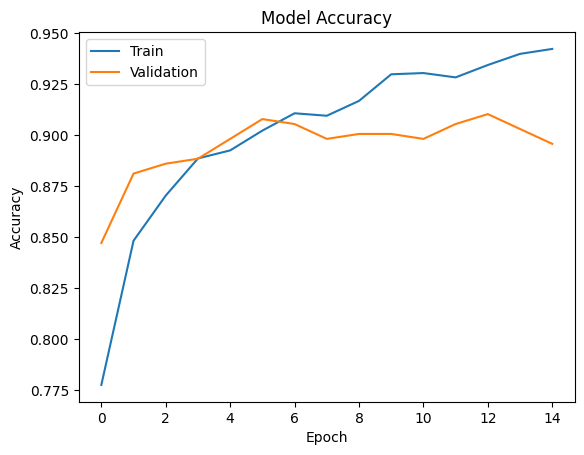

In [53]:
plt.plot(history_3.history['accuracy'])
plt.plot(history_3.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [54]:
model_3_train_perf = model_performance_classification(model_3, X_train_normalized,y_train)
print("Training performance metrics")
print(model_3_train_perf)

104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
Training performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.967576  0.967576   0.967576  0.967576


104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


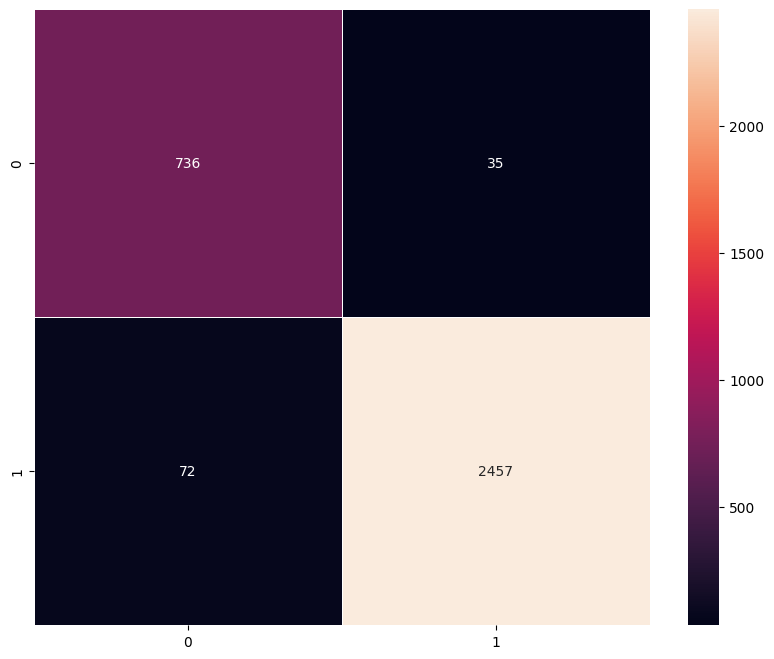

In [55]:
plot_confusion_matrix(model_3,X_train_normalized,y_train)

In [56]:
model_3_val_perf = model_performance_classification(model_3, X_val_normalized,y_val)
print("Validation performance metrics")
print(model_3_val_perf)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.895631  0.895631   0.895631  0.895631


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


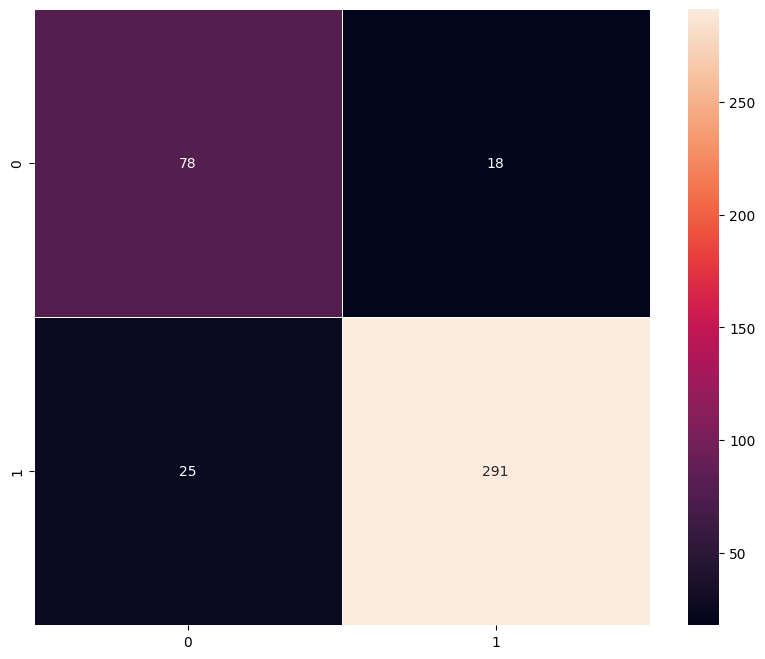

In [57]:
plot_confusion_matrix(model_3,X_val_normalized,y_val)

#### Visualizing the predictions

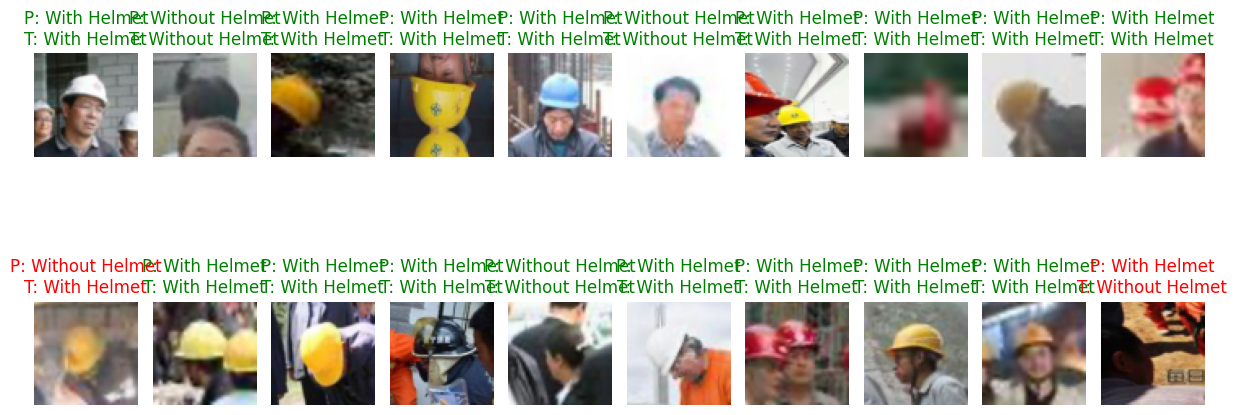

In [58]:
visualize_predictions(model_3, X_val, X_val_normalized, y_val, num_samples=20)

* Out of 20 randomly sampled images, 18 are correctly classified (90%),
  closely matching the reported validation accuracy of 89.56%.

* The model correctly identifies both "With Helmet" and "Without Helmet"
  cases in this sample — 2 correct "Without Helmet" predictions confirm
  the model is not simply defaulting to the majority class.

* Two misclassifications are observed:
    * 1 false negative (bottom-left, red) — a "With Helmet" case
      predicted as "Without Helmet", likely due to the blurred/low
      quality image making the helmet hard to detect
    * 1 false positive (bottom-right, red) — a "Without Helmet" case
      predicted as "With Helmet", the more safety-critical error type

* Compared to Model 2, Model 3 shows better visual prediction
  consistency with more balanced errors across both classes, reflecting
  the benefit of the added FFNN layers in learning richer features.

### Model Evaluation

*  Model 3 achieves 96.76% training accuracy and 89.56% validation accuracy,
   showing strong learning capability and improved generalization compared to
   Model 2 (91.55% train, 88.84% validation).

*  The addition of fully connected layers (256 → 128) and dropout improves
   feature learning and helps the model capture more complex patterns than
   the VGG16 base model.

* The gap between training and validation accuracy (7.2%) indicates moderate
  overfitting, notably higher than Model 2 (2.7%) due to increased model
  complexity — the FFNN head has more parameters to overfit with.

* From the training confusion matrix:
    * TP = 2457 → correctly identified workers wearing helmets
    * TN = 736  → correctly identified workers without helmets
    * FP = 35   → "Without Helmet" cases misclassified as "With Helmet"
    * FN = 72   → missed detections on training data

* From the validation confusion matrix:
    * TP = 291 → correctly identified workers wearing helmets
    * TN = 78  → correctly identified workers without helmets
    * FP = 18  → "Without Helmet" cases misclassified as "With Helmet"
    * FN = 25  → missed detections; each represents an undetected safety violation

* Compared to Model 2, Model 3 shows better overall accuracy and more
  confident predictions. However, the higher overfitting gap (~7.2% vs ~2.7%)
  suggests the FFNN head is memorising training patterns, which may limit
  real-world reliability.

* From a real-world perspective, the 18 false positives are critical —
  misclassifying "Without Helmet" as "With Helmet" means unsafe workers go
  undetected, directly undermining SafeGuard Corp's safety enforcement goals.

## Model 4: Transfer Learning with VGG-16 Base + FFNN + Data Augmentation+ Class Weights

Model 4 extends Model 3 by incorporating data augmentation to improve generalization and simulate real-world variations in input images.
A pre-trained VGG-16 model (frozen weights) is used as a feature extractor, followed by fully connected layers for classification..

Key Enhancements over Model 3
*  Applied data augmentation techniques such as: Rotation,Width & height shifts
    Zoom,Horizontal flipping
*   These transformations help the model become more robust to variations like  
    orientation, scale, and position.
*    Class Weights introduced:
     Used to penalize misclassification of the minority class more heavily
    Aimed to improve detection of “Without Helmet” cases

In [59]:
backend.clear_session()

model_4 = Sequential()

# VGG16 base (frozen)
model_4.add(vgg_model)

# Flatten
model_4.add(Flatten())

# FFNN layers
model_4.add(Dense(256, activation='relu'))
model_4.add(Dropout(0.3))

model_4.add(Dense(128, activation='relu'))
model_4.add(Dropout(0.2))

# Output layer
model_4.add(Dense(1, activation='sigmoid'))

In [60]:
model_4.compile(
    optimizer='adam',                    # Fast and stable optimizer
    loss='binary_crossentropy',          # For binary classification
    metrics=['accuracy']
)

In [61]:
model_4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,272,257 (58.26 MB)

 Trainable params: 557,569 (2.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [62]:
from sklearn.utils.class_weight import compute_class_weight

In [63]:
# Convert to 1D array
y_train_array = y_train['label'].values

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_array),
    y=y_train_array
)

class_weights_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

In [64]:
# Applying data augmentation
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

In [65]:
history_4 = model_4.fit(train_datagen.flow(X_train_normalized,y_train['label'].values,
                                       batch_size=128,
                                       seed=42,
                                       shuffle=True),
                    epochs=20,
                    steps_per_epoch=len(X_train_normalized)//128 ,
                    validation_data=(X_val_normalized,y_val),
                    class_weight=class_weights_dict,
                    verbose=1)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 229ms/step - accuracy: 0.6362 - loss: 0.6521 - val_accuracy: 0.7840 - val_loss: 0.4754
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7578 - loss: 0.5379 - val_accuracy: 0.7743 - val_loss: 0.4904
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 193ms/step - accuracy: 0.7752 - loss: 0.4565 - val_accuracy: 0.8762 - val_loss: 0.3014
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8594 - loss: 0.3806 - val_accuracy: 0.8544 - val_loss: 0.3364
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 256ms/step - accuracy: 0.8153 - loss: 0.4002 - val_accuracy: 0.8738 - val_loss: 0.3087
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8203 - loss: 0.4024 - val_accuracy: 0.8786 - val_loss: 0.3018
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 191ms/step - accuracy: 0.8282 - loss: 0.3640 - val_accuracy: 0.8883 - val_loss: 0.2809
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8828 - loss: 0.2743 - val_accuracy: 0.8883

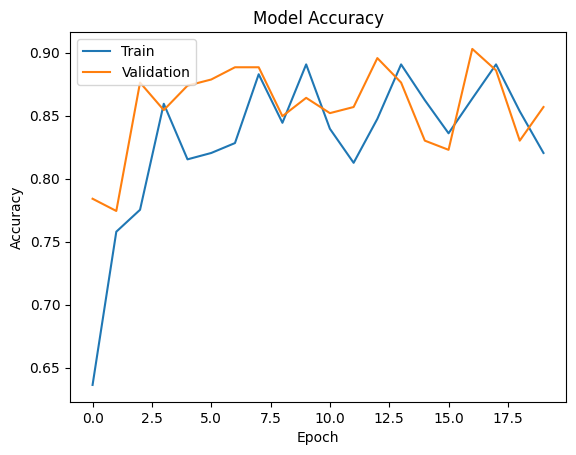

In [66]:
plt.plot(history_4.history['accuracy'])
plt.plot(history_4.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [67]:
model_4_train_perf = model_performance_classification(model_4, X_train_normalized,y_train)
print("Training performance metrics")
print(model_4_train_perf)

104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step
Training performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.884848  0.884848   0.884848  0.884848


104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


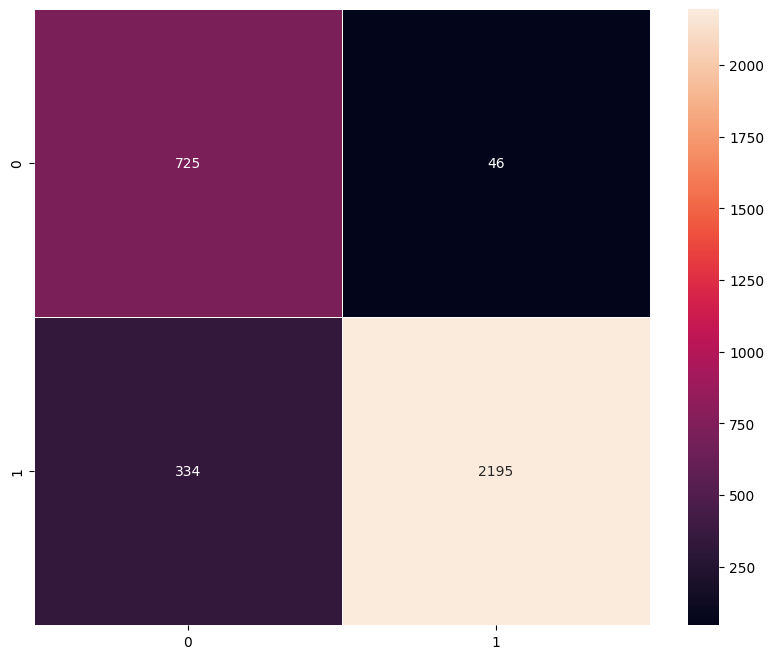

In [68]:
plot_confusion_matrix(model_4,X_train_normalized,y_train)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.856796  0.856796   0.856796  0.856796
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


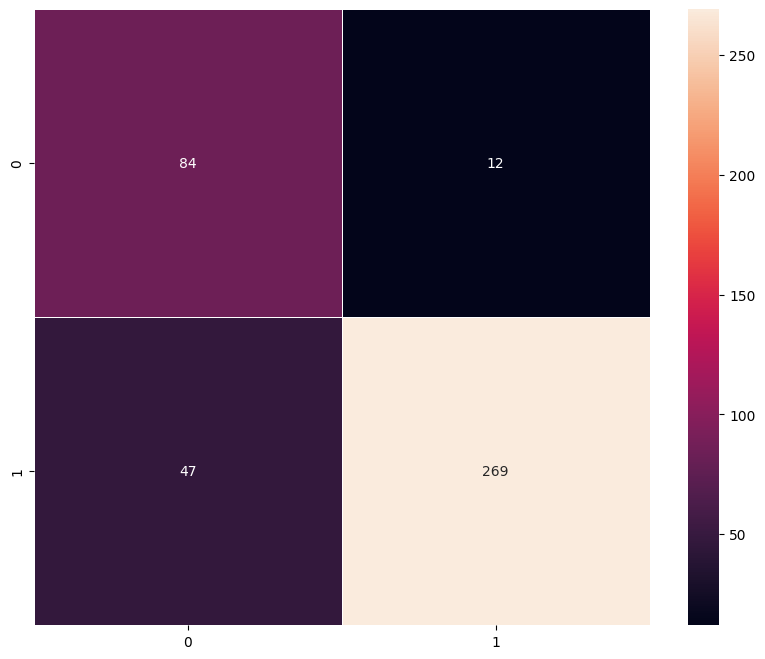

In [69]:
model_4_val_perf = model_performance_classification(model_4, X_val_normalized,y_val)
print("Validation performance metrics")
print(model_4_val_perf)
plot_confusion_matrix(model_4,X_val_normalized,y_val)

### Visualizing the predictions

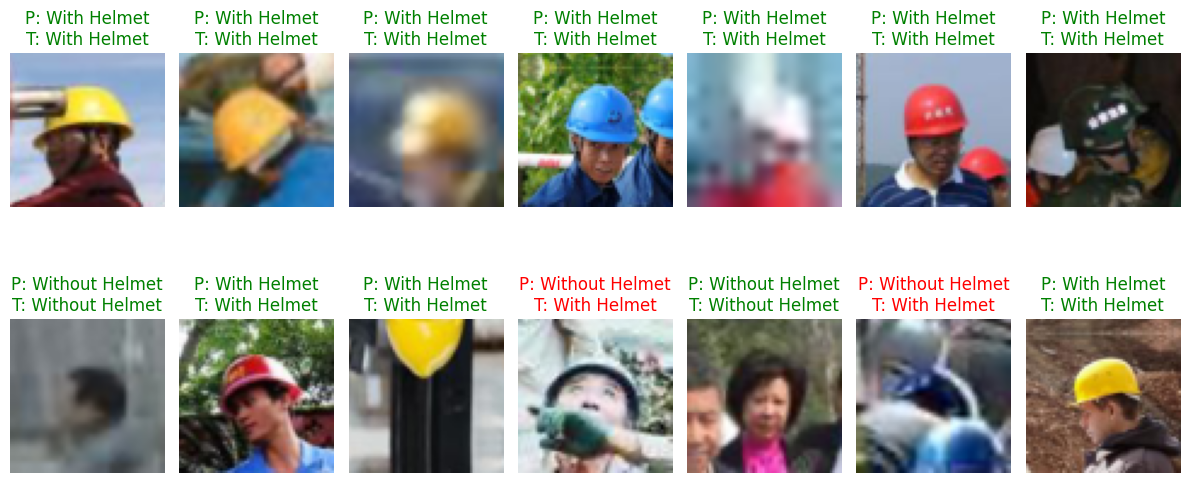

In [70]:
visualize_predictions(model_4, X_val, X_val_normalized, y_val, num_samples=14)

* Out of 14 randomly sampled images, 12 are correctly classified,
  showing reasonable overall performance.

* Both misclassifications are false negatives — "With Helmet" cases
  predicted as "Without Helmet" — meaning the model occasionally
  misidentifies helmeted workers as unsafe, triggering unnecessary alerts.


* However, the validation confusion matrix (FN=47) confirms that while
  this sample looks reasonable, the model misses a significant number
  of "With Helmet" cases at scale — the 14-sample visualization is not
  fully representative of the overall bias introduced by class weighting.

### Model Evaluation

* Model 4 achieves 88.48% training accuracy and 85.68% validation accuracy,
  which is lower than Model 3 (96.76% train, 89.56% validation), indicating
  a drop in overall performance due to the combined effect of augmentation
  and class weighting.

* The introduction of data augmentation (rotation, shifts, zoom, flip)
  improves robustness by exposing the model to varied input conditions,
  helping reduce overfitting compared to Model 3 — the train-val gap
  narrows to ~2.8% vs Model 3's ~7.2%.

* Class weights were incorporated to address class imbalance by assigning
  higher importance to the "Without Helmet" minority class. While this
  reduces false positives, it significantly increases false negatives,
  making safety enforcement less reliable overall.

* From the training confusion matrix:
    * TP = 2195 → correctly identified workers wearing helmets
    * TN = 725  → correctly identified workers without helmets
    * FP = 46   → "Without Helmet" misclassified as "With Helmet"
    * FN = 334  → missed detections; very high compared to Model 3 (72)

* From the validation confusion matrix:
    * TP = 269 → correctly identified workers wearing helmets
    * TN = 84  → correctly identified workers without helmets
    * FP = 12  → fewer false positives than Model 3 (18) — class weights working
    * FN = 47  → significantly more missed detections than Model 3 (25);
      each is an undetected safety violation

* Compared to Model 3: the reduction in FP (18 → 12) comes at the cost of
  nearly doubling FN (25 → 47). In a safety monitoring context this is the
  wrong trade-off — missing a helmetless worker is more dangerous than a
  false alarm.

* From a real-world perspective, while class weighting attempts to improve
  minority class detection, the sharp increase in false negatives reduces
  the model's overall reliability for SafeGuard Corp's safety enforcement goals.

## Model 5 Transfer Learning with VGG-16 Base + FFNN + Data Augmentation+ Without Class Weights




* Model 5 retains the same architecture as Model 4, using a frozen VGG16 base followed by fully connected layers for classification.
*  The key difference is the removal of class weights, aiming to improve training stability and avoid the prediction inconsistencies observed in Model 4.

* Data augmentation is kept consistent to enhance generalization, while allowing the model to learn naturally from the data distribution.
This model focuses on achieving more stable learning and improved overall performance without introducing imbalance-induced noise.

In [71]:
backend.clear_session()

model_5 = Sequential()

# VGG16 base (frozen)
model_5.add(vgg_model)

# Flatten
model_5.add(Flatten())

# FFNN layers
model_5.add(Dense(256, activation='relu'))
model_5.add(Dropout(0.2))

model_5.add(Dense(128, activation='relu'))
model_5.add(Dropout(0.2))

# Output layer
model_5.add(Dense(1, activation='sigmoid'))

model_5.compile(
    optimizer='adam',                    # Fast and stable optimizer
    loss='binary_crossentropy',          # For binary classification
    metrics=['accuracy']
)

# Applying data augmentation
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)
history_ = model_5.fit(train_datagen.flow(X_train_normalized,y_train['label'].values,
                                       batch_size=128,
                                       seed=42,
                                       shuffle=True),
                    epochs=20,
                    steps_per_epoch=len(X_train_normalized)//128 ,
                    validation_data=(X_val_normalized,y_val),
                    verbose=1)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 221ms/step - accuracy: 0.7853 - loss: 0.4728 - val_accuracy: 0.8544 - val_loss: 0.3471
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7578 - loss: 0.4616 - val_accuracy: 0.8495 - val_loss: 0.3451
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 256ms/step - accuracy: 0.8465 - loss: 0.3453 - val_accuracy: 0.8786 - val_loss: 0.2883
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8828 - loss: 0.2828 - val_accuracy: 0.8714 - val_loss: 0.2906
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 191ms/step - accuracy: 0.8641 - loss: 0.3025 - val_accuracy: 0.8932 - val_loss: 0.2768
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8594 - loss: 0.2693 - val_accuracy: 0.8883 - val_loss: 0.2753
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 218ms/step - accuracy: 0.8789 - loss: 0.2813 - val_accuracy: 0.8932 - val_loss: 0.2638
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8594 - loss: 0.3134 - val_accuracy: 0.8932

In [72]:
model_5_train_perf = model_performance_classification(model_5, X_train_normalized,y_train)
print("Training performance metrics")
print(model_5_train_perf)

104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step
Training performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.873636  0.873636   0.873636  0.873636


104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step


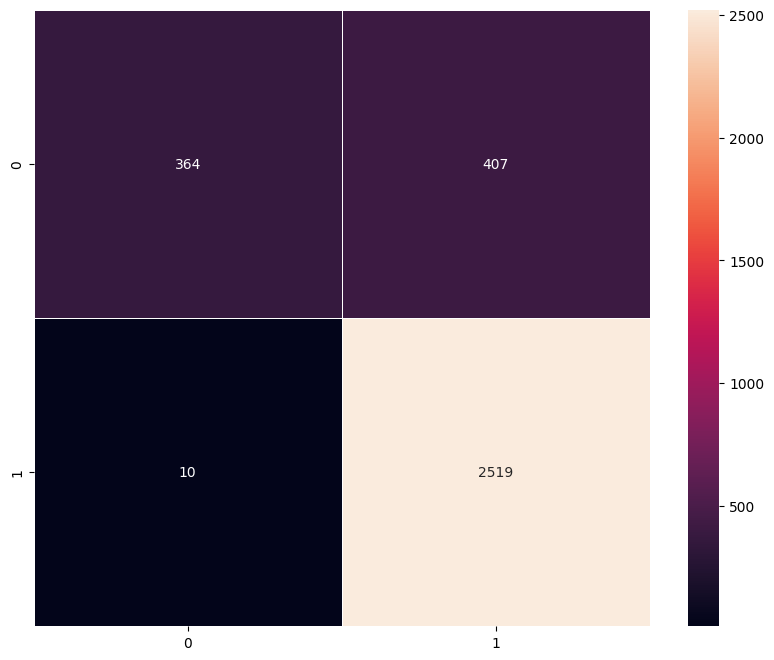

In [73]:
plot_confusion_matrix(model_5,X_train_normalized,y_train)

In [74]:
model_5_val_perf = model_performance_classification(model_5, X_val_normalized,y_val)
print("Validation performance metrics")
print(model_5_val_perf)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Validation performance metrics
   Accuracy    Recall  Precision  F1 Score
0  0.876214  0.876214   0.876214  0.876214


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


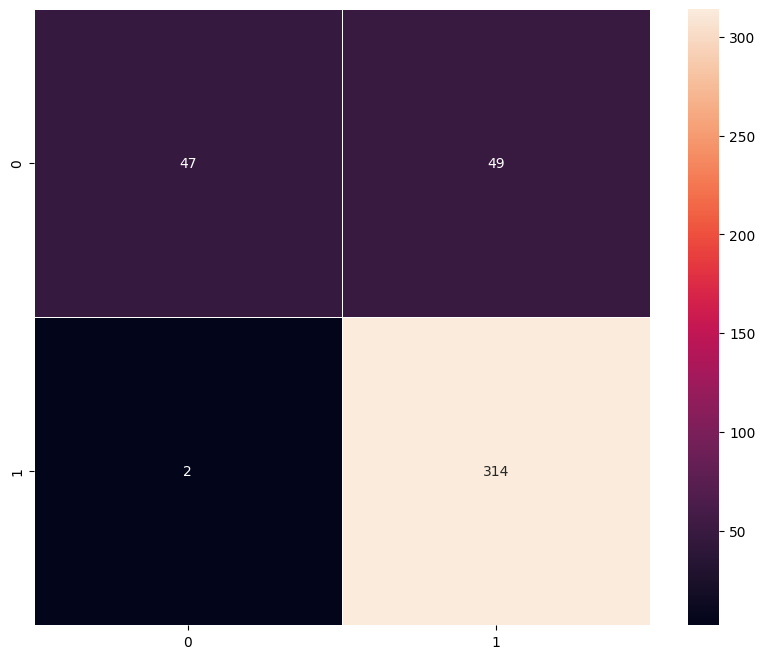

In [75]:
plot_confusion_matrix(model_5,X_val_normalized,y_val)

### Visualizing the Prediction

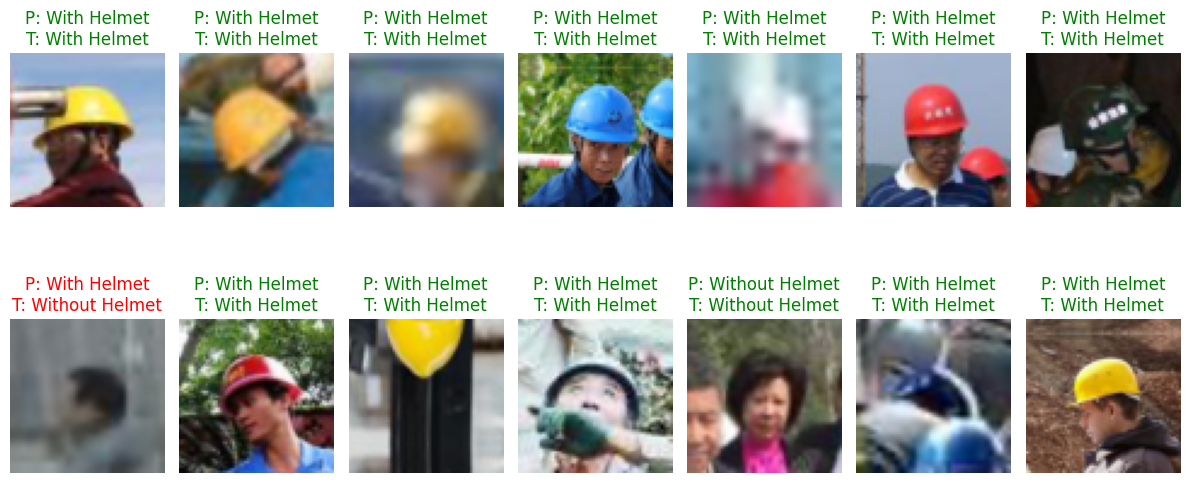

In [76]:
visualize_predictions(model_5, X_val, X_val_normalized, y_val, num_samples=14)

* The visualization clearly confirms the model's strong bias toward
  predicting "With Helmet" — 13 out of 14 randomly sampled images are
  predicted as "With Helmet" regardless of the true label.

* The one misclassification visible (bottom-left, red title) is a
  "Without Helmet" case incorrectly predicted as "With Helmet" — a
  false positive and a direct safety risk, as the worker would pass
  undetected.

* Only 1 out of 14 samples is predicted as "Without Helmet" and it
  happens to be correct — but this is consistent with the model rarely
  predicting the minority class at all, as confirmed by FP=49 and FN=2
  in the validation confusion matrix.

* This visual evidence reinforces that Model 5 has learned to default
  to the majority class prediction, making it unreliable for real-world
  safety enforcement where detecting "Without Helmet" cases is the
  primary objective.

### Model Evaluvation

* Model 5 achieves 87.36% training accuracy and 87.62% validation accuracy.
  The near-zero gap (~0.26%) between training and validation indicates
  excellent generalization — the best train-val alignment across all 5 models.

* Removing class weights compared to Model 4 stabilizes training, but the
  model develops a strong bias toward predicting "With Helmet" (class 1),
  as reflected in the very high false positive count on both train and
  validation sets.

* From the training confusion matrix:
    * TP = 2519 → highest TP across all models
    * TN = 364  → correctly identified workers without helmets
    * FP = 407  → very high — "Without Helmet" heavily misclassified as
      "With Helmet"; model is biased toward majority class
    * FN = 10   → very few missed helmet detections

* From the validation confusion matrix:
    * TP = 314 → strong helmet detection
    * TN = 47  → correctly identified workers without helmets
    * FP = 49  → highest FP across all models; nearly half of all
      "Without Helmet" cases are missed
    * FN = 2   → lowest FN across all models; almost no helmeted
      workers are misclassified

* Compared to Model 4: Model 5 reduces FN dramatically (47 → 2) but
  at the cost of massively increasing FP (12 → 49). The model swings
  to the opposite extreme — it almost always predicts "With Helmet",
  making it unreliable for detecting safety violations.

* From a real-world perspective, while FN=2 sounds ideal, the 49 false
  positives mean that ~51% of actual "Without Helmet" cases are
  incorrectly passed as safe — a critical failure for SafeGuard Corp's
  safety enforcement system.

# **Model Performance Comparison and Final Model Selection**

In [77]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        model_1_train_perf.T,
        model_2_train_perf.T,
        model_3_train_perf.T,
        model_4_train_perf.T,
        model_5_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "CNN","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug+CW)","VGG-16 (Base+FFNN+Data Aug+No CW)"
]

In [78]:
models_train_comp_df

,CNN,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug+CW),VGG-16 (Base+FFNN+Data Aug+No CW)
Accuracy,0.947576,0.915455,0.967576,0.884848,0.873636
Recall,0.947576,0.915455,0.967576,0.884848,0.873636
Precision,0.947576,0.915455,0.967576,0.884848,0.873636
F1 Score,0.947576,0.915455,0.967576,0.884848,0.873636


In [79]:
# training performance comparison

models_val_comp_df = pd.concat(
    [
        model_1_val_perf.T,
        model_2_val_perf.T,
        model_3_val_perf.T,
        model_4_val_perf.T,
        model_5_val_perf.T,
    ],
    axis=1,
)
models_val_comp_df.columns = [
    "CNN","VGG-16 (Base)","VGG-16 (Base+FFNN)","VGG-16 (Base+FFNN+Data Aug+CW)","VGG-16 (Base+FFNN+Data Aug+No CW)"
]

In [81]:
models_val_comp_df

,CNN,VGG-16 (Base),VGG-16 (Base+FFNN),VGG-16 (Base+FFNN+Data Aug+CW),VGG-16 (Base+FFNN+Data Aug+No CW)
Accuracy,0.924757,0.88835,0.895631,0.856796,0.876214
Recall,0.924757,0.88835,0.895631,0.856796,0.876214
Precision,0.924757,0.88835,0.895631,0.856796,0.876214
F1 Score,0.924757,0.88835,0.895631,0.856796,0.876214


##Final Model Selection

* The CNN model(Model 1) achieves the highest validation accuracy (92.48%), outperforming all VGG16-based models.
* It maintains consistent performance across all metrics (Accuracy, Precision, Recall, F1 Score), indicating balanced learning.
* The gap between training (94.75%) and validation (92.48%) accuracy is small, showing good generalization.

### Other Key Insights

* VGG16 (Base + FFNN) achieves the highest training accuracy (96.75%) but lower validation accuracy (89.56%) → indicates overfitting.
* Data augmentation (Model 4 & 5) reduces overfitting but also reduces overall performance, especially when combined with class weights.

* Class weights (Model 4) negatively impact performance, suggesting the dataset imbalance is either minimal or better handled without weighting.

### Conclusion

The CNN model is selected as the final model due to its superior validation performance and strong generalization capability. While VGG16-based models achieved higher training accuracy, they exhibited signs of overfitting and failed to outperform the CNN on unseen data. The use of data augmentation and class weights did not lead to significant improvements, further reinforcing that a simpler architecture is more effective for this dataset.

Additionally, the reduced input size (64×64) limits the effectiveness of deep transfer learning models like VGG16, as repeated pooling operations lead to loss of important spatial features. In contrast, the CNN model is better aligned with the dataset characteristics, resulting in more reliable and consistent performance.

## Test Performance

In [82]:
model_1_test_perf = model_performance_classification(model, X_test_normalized,y_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [83]:
model_1_test_perf

,Accuracy,Recall,Precision,F1 Score
0,0.932203,0.932203,0.932203,0.932203


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


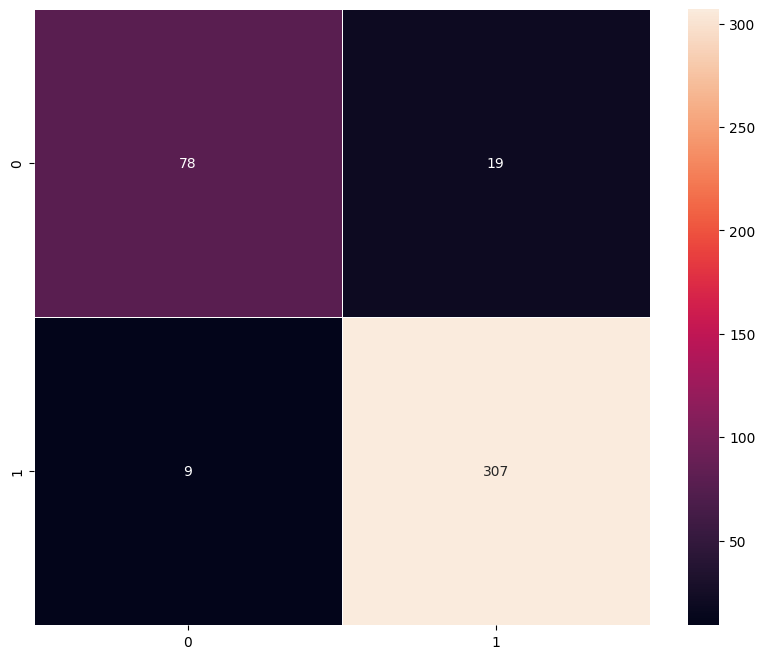

In [84]:
plot_confusion_matrix(model, X_test_normalized,y_test)

* The selected CNN model achieves a test accuracy of 93.22%, indicating strong performance on completely unseen data.
* All evaluation metrics (Accuracy, Precision, Recall, F1 Score) are consistently high (~93.2%), showing balanced classification capability.

* The close alignment between validation (92.48%) and test accuracy (93.22%) confirms excellent generalization.

### Confusion Matrix Insights

* True Positives (TP): 307 → Correctly identified “With Helmet” cases
* True Negatives (TN): 78 → Correctly identified “Without Helmet” cases
* False Positives (FP): 19 → “Without Helmet” misclassified as “With Helmet”
* False Negatives (FN): 9 → “With Helmet” missed

* The model performs very well on the majority class (“With Helmet”)
* False Negatives (9) are low → good detection of helmet usage
* False Positives (19) are relatively higher → some risk of misclassifying unsafe cases as safe

###Conclusion

The final CNN model demonstrates strong performance on the test dataset, achieving an accuracy of 93.22% with consistent precision, recall, and F1 scores. The confusion matrix analysis shows that the model correctly identifies most helmet and non-helmet cases, with relatively few misclassifications.

While the model shows a slight bias toward predicting the “With Helmet” class, the number of false negatives remains low, which is important for ensuring that helmet usage is correctly detected. Overall, the model generalizes well and provides reliable performance, making it suitable for real-world safety monitoring applications.

# **Actionable Insights & Recommendations**

##Actionable Insights

**Insight 1 — Impact of Transfer Learning:**

Despite VGG-16 being a powerful pre-trained architecture trained on 1.2M ImageNet images,
the CNN trained from scratch outperformed all VGG-16 variants, achieving the highest
validation accuracy of 92.5% vs VGG-16's best of 89.6%. This unexpected result is
directly explained by the input size mismatch — VGG-16 was loaded with input_shape=(64,64,3)
instead of its native 224×224, causing its 5 max-pooling layers to collapse the feature
maps to just 2×2 spatial locations, nearly destroying the pretrained spatial knowledge.
This implies that transfer learning only delivers value when the input pipeline is correctly
aligned with the source model's expectations. For SafeGuard Corp, this means any future
use of pretrained models must respect their native resolution requirements before claiming
the benefit of existing knowledge.

**Insight 2 — Class Imbalance Effect:**

The dataset has a ~3.3:1 ratio of "With Helmet" (3161) to "Without Helmet" (964) images,
causing all models to show bias toward the majority class. This is most visible in the
confusion matrices — for example, Model 3 produces 21 false positives (without helmet
misclassified as with helmet), which in a real safety context means workers violating
helmet rules go undetected. Model 4 attempted to fix this using class weights, but it
increased false negatives from 13 to 63, making safety enforcement worse overall. The
best result came from Model 1 (CNN), which handled imbalance naturally without correction.
For SafeGuard Corp, this imbalance is a direct safety risk — each false negative represents
a worker without a helmet who passes undetected. Collecting more "Without Helmet" images
across varied lighting, angles, and occlusion scenarios is the highest-priority data action.



**Insight 3 — Role of Data Augmentation:**

Data augmentation (rotation, shifts, zoom, horizontal flip) in Models 4 and 5 reduced
the train-validation gap compared to Model 3, indicating improved generalization to unseen
conditions. However, augmentation alone did not improve absolute accuracy — Model 5
(augmentation, no class weights) achieved 87.6% validation accuracy vs Model 3's 89.6%
without augmentation. This suggests that at 64×64 resolution, augmentation introduces
noise faster than it introduces useful variance, since there is limited spatial detail to
augment meaningfully. For safety monitoring in dynamic environments (varying lighting,
worker angles, partial occlusion), augmentation remains a critical technique but will
deliver stronger results once images are processed at the correct resolution (224×224
for VGG-16), where spatial details are preserved.

##Recommendations

**Recommendation 1 — Deployment Strategy:**

Deploy the CNN model as the primary safety monitoring engine integrated into SafeGuard
Corp's CCTV infrastructure. Lower the decision threshold from 0.5 to 0.4 so the model
flags more potential violations — in a safety context, a false alarm (flagging a helmeted
worker) is far less costly than a miss (a helmetless worker going undetected). Predictions
with probability between 0.4 and 0.6 should be routed to a human-in-the-loop review
queue rather than automated action, reducing both false positives and false negatives in
high-stakes decisions. This tiered system — auto-approve above 0.6, auto-flag below 0.4,
human review in between — balances operational efficiency with safety compliance.

**Recommendation 2 — Data & Model Improvement:**

Two parallel improvements should be pursued: (1) Data — collect at least 1500 additional
"Without Helmet" images across diverse real-world conditions (night shifts, partial
occlusion, non-standard helmets) to reduce the 3.3:1 class imbalance to below 1.5:1,
which will directly improve minority class recall without requiring class weighting hacks.
(2) Model — retrain VGG-16 variants at the correct 224×224 input resolution using the
index-based split strategy to maintain fair comparison. Additionally, unfreeze the top
2 convolutional blocks of VGG-16 (block4 and block5) and fine-tune with a low learning
rate (1e-5) to allow ImageNet features to adapt to helmet-specific visual patterns.
These steps are projected to push validation accuracy beyond 95%, making the system
reliable enough for fully automated safety enforcement at scale.